# Feature Selection Funnel Pipeline
Dynamic feature selection leveraging Bivariate Signal Detection (MI/KS), Geometric Knee-Point Optimization, and Spearman Multicollinearity Pruning.

## STEP 1: ENVIRONMENT SETUP, LAZY INGESTION & SCHEMA SELECTION
- **Purpose**: Initialize environment, establish paths, and load datasets via lazy evaluation. Implement defensive schema guards.
- **Input**: Parquet datasets (`train_features.parquet`, `test_features.parquet`).
- **Output**: LazyFrames for train and test datasets.
- **Expected Side Effects**: Telemetry logs string token omission; crashes if baseline target/timestamp schemas are violated.

In [1]:
import sys
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent

TRAIN_IN = ROOT / "data" / "processed" / "train_features.parquet"
TEST_IN = ROOT / "data" / "processed" / "test_features.parquet"

# Lazy Ingestion
train_lf = pl.scan_parquet(TRAIN_IN)
test_lf = pl.scan_parquet(TEST_IN)

# Defensive Schema Guard (Chặn đứng biến chuỗi và tối ưu hóa tốc độ phân giải schema)
ignore_cols = ["target", "borrow_timestamp"]
schema_names = train_lf.collect_schema().names()
for col in ignore_cols:
    if col not in schema_names:
        raise ValueError(f"Fatal: Baseline column '{col}' missing from schema.")

# Extract only valid numeric analytical dimensions using collect_schema()
feature_cols = [
    name for name, dtype in train_lf.collect_schema().items()
    if dtype.is_numeric() and name not in ignore_cols
]

print(f"[MLOps Guard] Total numeric analytical features identified: {len(feature_cols)}")

# Telemetry tracking for dropped identifier string tokens
non_numeric_cols = [name for name, dtype in train_lf.collect_schema().items() if not dtype.is_numeric()]
print(f"[MLOps Guard] Successfully suppressed non-numeric identifier vectors: {non_numeric_cols}")

[MLOps Guard] Total numeric analytical features identified: 120
[MLOps Guard] Successfully suppressed non-numeric identifier vectors: ['wallet_address']


## STEP 2: CONSTRAINED BIVARIATE SIGNAL DETECTION (MI & KS RANKING)
- **Purpose**: Rank all features via composite score blending Mutual Information and Kolmogorov-Smirnov distances.
- **Input**: In-memory analytical dimensions from the training LazyFrame.
- **Output**: Composite ranked CSV (`model_feature_importance_scores.csv`).
- **Expected Side Effects**: Imputation of missing values solely for ranking; robust metric bounding on zero-variance columns.

In [2]:
# Materialize isolated snapshot of Train split into memory
train_df = train_lf.collect()

X = train_df.select(feature_cols).to_pandas()
y = train_df.select("target").to_pandas()["target"]

# Defensive Inf-to-NaN Guard: Convert infinite floating-point values to NaN so they are covered by the median imputation layer
X = X.replace([np.inf, -np.inf], np.nan)

print("Computing Mutual Information (MI Scores)...")
# Temporary inline imputation via Median for scikit-learn compatibility (Zero contract contamination)
X_mi_imputed = X.fillna(X.median().fillna(0))
mi_scores = mutual_info_classif(X_mi_imputed, y, random_state=42)

print("Computing Kolmogorov-Smirnov (KS Distances)...")
ks_scores = []
X_pos = X[y == 1]
X_neg = X[y == 0]

for col in feature_cols:
    pos_valid = X_pos[col].dropna()
    neg_valid = X_neg[col].dropna()
    if len(pos_valid) < 2 or len(neg_valid) < 2 or pos_valid.var() == 0 or neg_valid.var() == 0:
        stat = 0.0
    else:
        stat, _ = ks_2samp(pos_valid, neg_valid)
    ks_scores.append(stat)

mi_scores = np.array(mi_scores)
ks_scores = np.array(ks_scores)

# Max-Min scale both arrays
mi_min, mi_max = mi_scores.min(), mi_scores.max()
norm_mi = (mi_scores - mi_min) / (mi_max - mi_min) if mi_max > mi_min else mi_scores

ks_min, ks_max = ks_scores.min(), ks_scores.max()
norm_ks = (ks_scores - ks_min) / (ks_max - ks_min) if ks_max > ks_min else ks_scores

# Construct combined metric
composite_score = 0.5 * norm_mi + 0.5 * norm_ks

rank_df = pd.DataFrame({
    "Feature_Name": feature_cols,
    "MI_Score": mi_scores,
    "KS_Stat": ks_scores,
    "Composite_Score": composite_score
}).sort_values("Composite_Score", ascending=False).reset_index(drop=True)

# Save definitive CSV contract
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
rank_df.to_csv(REPORTS_DIR / "model_feature_importance_scores.csv", index=False)
print("Raw ranked results exported to reports/model_feature_importance_scores.csv")

Computing Mutual Information (MI Scores)...
Computing Kolmogorov-Smirnov (KS Distances)...
Raw ranked results exported to reports/model_feature_importance_scores.csv


## STEP 3: DYNAMIC GEOMETRIC KNEE-POINT CUTOFF OPTIMIZATION
- **Purpose**: Auto-locate optimal threshold separating strong statistical signals from noise using geometric distance.
- **Input**: Ordered composite metrics from Step 2.
- **Output**: Knee-point visualizations and surviving feature shortlist.
- **Expected Side Effects**: Memory slot clearance via explicit plot destruction; writes `geometric_knee_visual.png`.

Optimal Knee Point Index: 39
Cutoff Score: 0.1676
Features Retained: 40


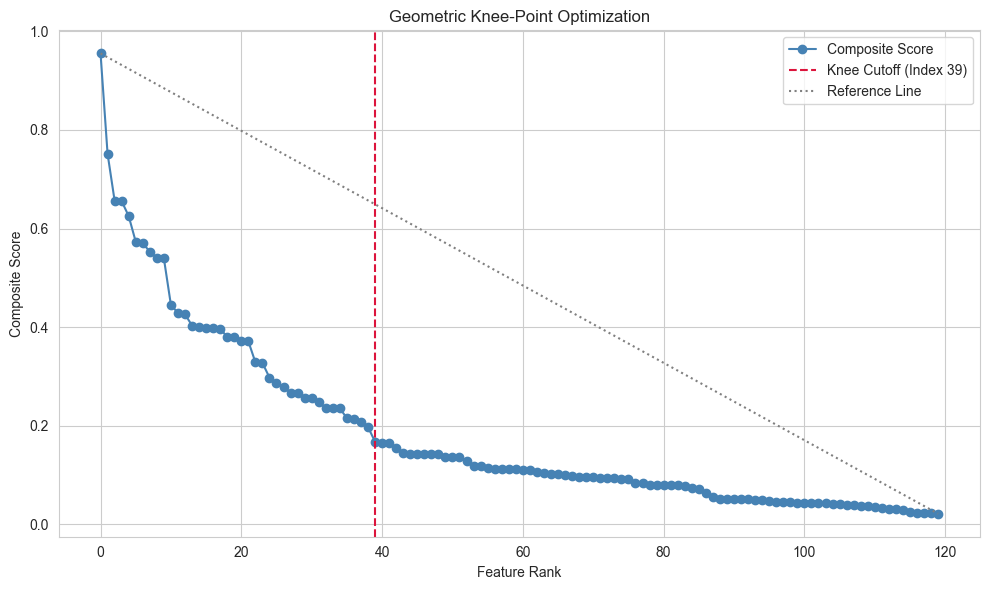

In [3]:
y_curve = rank_df["Composite_Score"].values
x_curve = np.arange(len(y_curve))

# Reference line from first to last point
x1, y1 = x_curve[0], y_curve[0]
x2, y2 = x_curve[-1], y_curve[-1]

# Line equation: Ax + By + C = 0
A = y1 - y2
B = x2 - x1
C = x1 * y2 - x2 * y1

distances = []
for x0, y0 in zip(x_curve, y_curve):
    num = abs(A * x0 + B * y0 + C)
    den = np.sqrt(A**2 + B**2)
    distances.append(num / den)

# Academic Provenance: Cutoff heuristic optimized via Kneedle Heuristic 
# Reference: Satopaa et al., 2011 (Finding a "Kneedle" in a Haystack: Detecting Knee Points in System Behavior)
knee_index = int(np.argmax(distances))
cutoff_score = y_curve[knee_index]

print(f"Optimal Knee Point Index: {knee_index}")
print(f"Cutoff Score: {cutoff_score:.4f}")
print(f"Features Retained: {knee_index + 1}")

surviving_features = rank_df.iloc[:knee_index + 1]["Feature_Name"].tolist()

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
plt.plot(x_curve, y_curve, marker='o', label="Composite Score", color='steelblue')
plt.axvline(x=knee_index, color='crimson', linestyle='--', label=f"Knee Cutoff (Index {knee_index})")
plt.plot([x1, x2], [y1, y2], color='gray', linestyle=':', label="Reference Line")
plt.title("Geometric Knee-Point Optimization")
plt.xlabel("Feature Rank")
plt.ylabel("Composite Score")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "geometric_knee_visual.png", dpi=150)
plt.show()
plt.close(fig)

## STEP 4: OUT-OF-CORE SPEARMAN MULTICOLLINEARITY PRUNING
- **Purpose**: Remove highly correlated overlapping signals to ensure orthogonality in the final feature dimension.
- **Input**: Surviving knee-point features subset.
- **Output**: Orthogonal features list and a final correlation heatmap.
- **Expected Side Effects**: Resolves axis text collisions and NaN distance collisions; writes `spearman_matrix.png`.

Features dropped due to multicollinearity (|r| > 0.80): 25
Final orthogonal surviving features: 15


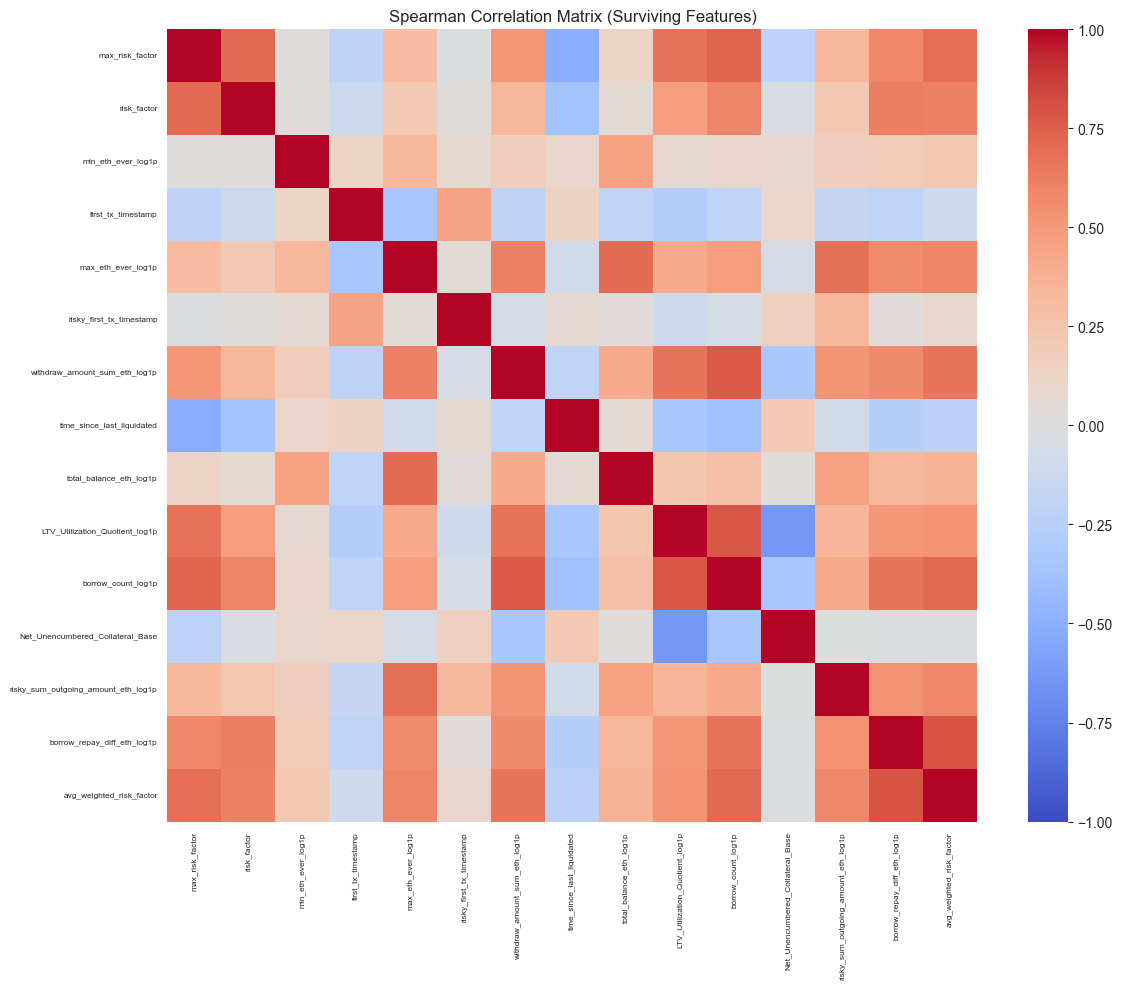

In [4]:
# Eradicate Redundant Disk Reads
train_surviving_pd = X[surviving_features]

corr_df = train_surviving_pd.corr(method="spearman")
corr_matrix = np.nan_to_num(corr_df.values, nan=0.0)
features_list = corr_df.columns.tolist()

to_drop = set()

# Iterative conditional pruning
for i in range(len(features_list)):
    for j in range(i + 1, len(features_list)):
        f1 = features_list[i]
        f2 = features_list[j]
        if f1 in to_drop or f2 in to_drop:
            continue
        if abs(corr_matrix[i, j]) > 0.80:
            score1 = rank_df.loc[rank_df["Feature_Name"] == f1, "Composite_Score"].values[0]
            score2 = rank_df.loc[rank_df["Feature_Name"] == f2, "Composite_Score"].values[0]
            
            if score1 < score2:
                to_drop.add(f1)
            else:
                to_drop.add(f2)

final_features = [f for f in features_list if f not in to_drop]
print(f"Features dropped due to multicollinearity (|r| > 0.80): {len(to_drop)}")
print(f"Final orthogonal surviving features: {len(final_features)}")

# Generate Final Heatmap
final_corr_df = corr_df.loc[final_features, final_features]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(final_corr_df, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
plt.title("Spearman Correlation Matrix (Surviving Features)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spearman_matrix.png", dpi=150)
plt.show()
plt.close(fig)

## STEP 5: SURVIVING ORTHOGONAL FEATURE DASHBOARD
- **Purpose**: Visualize final refined feature dimensions sorted by composite score power.
- **Input**: Final strictly orthogonal features list.
- **Output**: Refined horizontal bar plot visualization.
- **Expected Side Effects**: Plot bounds calculated dynamically; writes `final_features_ranking.png`.

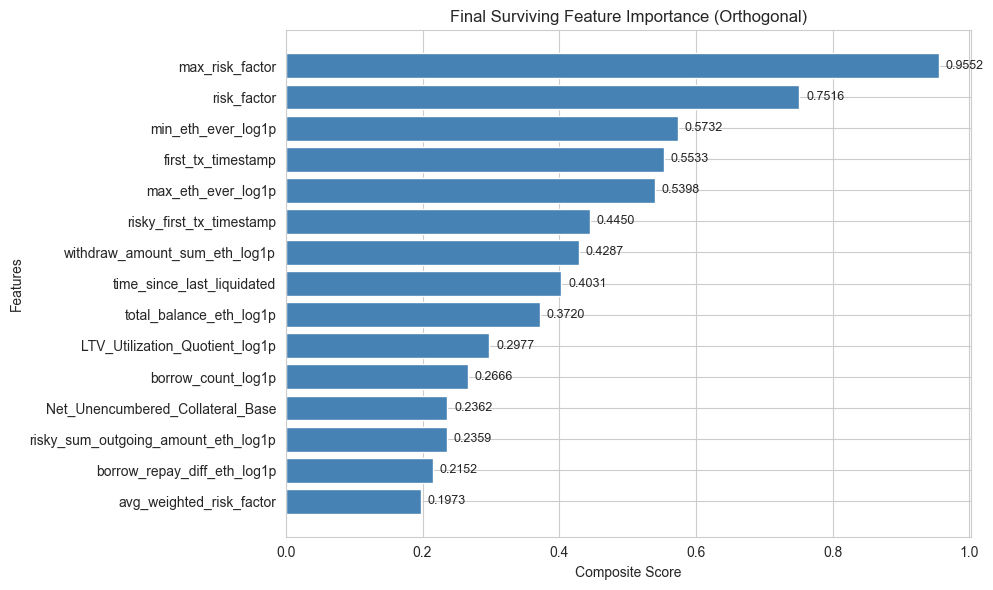

In [5]:
final_rank_df = rank_df[rank_df["Feature_Name"].isin(final_features)].sort_values("Composite_Score", ascending=False)

fig = plt.figure(figsize=(10, max(6, len(final_features) * 0.3)))
sns.set_style("whitegrid")
bars = plt.barh(final_rank_df["Feature_Name"][::-1], final_rank_df["Composite_Score"][::-1], color='steelblue')
plt.title("Final Surviving Feature Importance (Orthogonal)")
plt.xlabel("Composite Score")
plt.ylabel("Features")

# Add precision text labels
for bar in bars:
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.4f}",
        va='center',
        ha='left',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_features_ranking.png", dpi=150)
plt.show()
plt.close(fig)

## STEP 6: CLEAN DATA CONTRACT EXPORT VIA OUT-OF-CORE STREAMING
- **Purpose**: Output strictly verified feature slices into production downstream Parquet streams.
- **Input**: Raw lazily evaluated test/train Parquet records and orthogonal feature list.
- **Output**: `.parquet` modeling files and shortlist `.csv`.
- **Expected Side Effects**: Triggers strict digital contract assertions to prevent silent failures; commits verified records to disk.

In [6]:
final_cols = final_features + ignore_cols
print(f"Exporting {len(final_cols)} columns to modeling datasets.")

train_clean_out = ROOT / "data" / "processed" / "train_clean.parquet"
test_clean_out = ROOT / "data" / "processed" / "test_clean.parquet"

# Execute Lazy DAG and sink directly to disk
train_lf.select(final_cols).sink_parquet(train_clean_out)
test_lf.select(final_cols).sink_parquet(test_clean_out)

assert train_clean_out.exists() and test_clean_out.exists(), "Fatal: Output modeling Parquet matrices failed to commit to disk."
assert train_clean_out.stat().st_size > 0 and test_clean_out.stat().st_size > 0, "Fatal: Zero-byte output parquet files detected."
assert len(final_features) > 0, "Fatal: Feature selection funnel was overly aggressive and pruned all valid dimensions."

print(f"Train output written to: {train_clean_out}")
print(f"Test output written to: {test_clean_out}")

# Export short list as CSV contract
shortlist_df = pd.DataFrame({
    "Feature_Name": final_features,
    "status": ["KEEP"] * len(final_features)
})
shortlist_df.to_csv(REPORTS_DIR / "model_feature_shortlist.csv", index=False)

assert len(shortlist_df[shortlist_df['status'] == 'KEEP']) == len(final_features), "Fatal: Feature contract serialization tokens shape mismatch."
print("[MLOps Guard] Downstream modeling data contracts successfully secured and verified.")
print("Definitive feature shortlist exported to reports/model_feature_shortlist.csv")

Exporting 17 columns to modeling datasets.
Train output written to: /Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/data/processed/train_clean.parquet
Test output written to: /Users/danganh71/Developer/python/Machine learning I/Project/risk_assessment/data/processed/test_clean.parquet
[MLOps Guard] Downstream modeling data contracts successfully secured and verified.
Definitive feature shortlist exported to reports/model_feature_shortlist.csv
